# いびきデータ解析

M5GO のマイク音量ログ（1日分）を解析する。

- `level`: マイクの音量レベル
- `snoring`: 記録時の判定（`level > THRESHOLD` で 1）。本ノートブックでは閾値を再検討する。

In [1]:
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import japanize_matplotlib  # noqa: F401  日本語フォント

# 同じフォルダの最新CSVを自動で読む
csv_path = sorted(glob.glob("snore_*.csv"))[-1]
print("読み込み:", csv_path)

df = pd.read_csv(csv_path, parse_dates=["timestamp"])

# データクリーニング: センサーの桁化けによる異常値を除去
# M5GOのマイクlevelは現実的に数万が上限。それを大きく超える値はグリッチ。
LEVEL_MAX = 100_000
n_bad = (df["level"] > LEVEL_MAX).sum()
if n_bad:
    print(f"異常値を除去: {n_bad} 件 (level > {LEVEL_MAX:,})")
df = df[df["level"] <= LEVEL_MAX].reset_index(drop=True)

df.head()

読み込み: snore_20260603_005821.csv
異常値を除去: 1 件 (level > 100,000)


,timestamp,level,snoring
0,2026-06-03 00:58:21,793,0
1,2026-06-03 00:58:21,809,0
2,2026-06-03 00:58:21,643,0
3,2026-06-03 00:58:21,608,0
4,2026-06-03 00:58:21,643,0


## 1. 記録の概要

In [2]:
start = df["timestamp"].min()
end = df["timestamp"].max()
duration = end - start
dur_h = duration.total_seconds() / 3600

print(f"記録開始     : {start}")
print(f"記録終了     : {end}")
print(f"記録時間     : {duration}  ({dur_h:.2f} 時間)")
print(f"総サンプル数 : {len(df):,}")
print(f"平均サンプリングレート: {len(df) / duration.total_seconds():.1f} 件/秒")

記録開始     : 2026-06-03 00:58:21
記録終了     : 2026-06-03 07:51:04
記録時間     : 0 days 06:52:43  (6.88 時間)
総サンプル数 : 4,291
平均サンプリングレート: 0.2 件/秒


## 2. 音量レベルの分布

count     4291.000000
mean      2455.841296
std       5193.750518
min        476.000000
25%       1228.000000
50%       1324.000000
75%       1460.500000
max      61956.000000
Name: level, dtype: float64

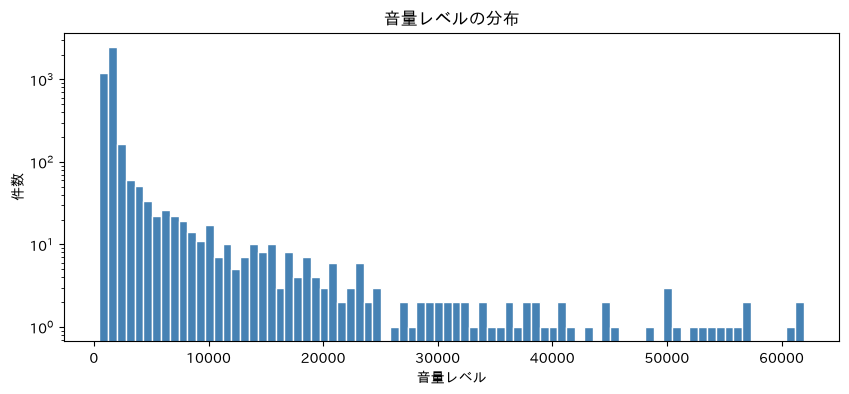

In [3]:
display(df["level"].describe())

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(df["level"], bins=80, color="steelblue", edgecolor="white")
ax.set_xlabel("音量レベル")
ax.set_ylabel("件数")
ax.set_title("音量レベルの分布")
ax.set_yscale("log")  # 静かな時間が大半なので対数軸
plt.show()

## 3. いびき判定の閾値

記録時は `THRESHOLD = 2500`。分位点を見て妥当性を確認する。

In [4]:
THRESHOLD = 2500

for q in [0.5, 0.75, 0.9, 0.95, 0.99, 0.999]:
    print(f"{q*100:5.1f} パーセンタイル: {df['level'].quantile(q):8.0f}")

snore = df[df["level"] > THRESHOLD]
print(f"\n閾値 {THRESHOLD} 超え       : {len(snore):,} 件 ({len(snore)/len(df)*100:.2f}%)")

 50.0 パーセンタイル:     1324
 75.0 パーセンタイル:     1460
 90.0 パーセンタイル:     2867
 95.0 パーセンタイル:     7723
 99.0 パーセンタイル:    30275
 99.9 パーセンタイル:    56767

閾値 2500 超え       : 485 件 (11.30%)


## 4. いびきイベントの抽出

閾値を超えるサンプルが連続するまとまりを「1いびき」として数える（途中3秒以内のギャップは同一イベントとみなす）。

In [5]:
GAP_SEC = 3  # この秒数以内に次の検出があれば同じイベント

ev = snore.sort_values("timestamp").copy()
gap = ev["timestamp"].diff().dt.total_seconds()
ev["episode"] = (gap > GAP_SEC).cumsum()

episodes = ev.groupby("episode").agg(
    start=("timestamp", "min"),
    end=("timestamp", "max"),
    peak_level=("level", "max"),
    samples=("level", "size"),
)
episodes["duration_s"] = (episodes["end"] - episodes["start"]).dt.total_seconds()

print(f"いびきイベント数: {len(episodes)}")
print(f"最大ピーク音量  : {episodes['peak_level'].max()}")
print(f"最長いびき      : {episodes['duration_s'].max():.0f} 秒")
episodes.head(10)

いびきイベント数: 4
最大ピーク音量  : 61956
最長いびき      : 1 秒


,start,end,peak_level,samples,duration_s
episode,,,,,
0,2026-06-03 00:58:22,2026-06-03 00:58:23,3181,8,1.0
1,2026-06-03 00:58:58,2026-06-03 00:58:59,14749,15,1.0
2,2026-06-03 01:00:59,2026-06-03 01:01:00,61956,456,1.0
3,2026-06-03 02:40:28,2026-06-03 02:40:28,4410,6,0.0


## 5. 一晩の音量タイムライン

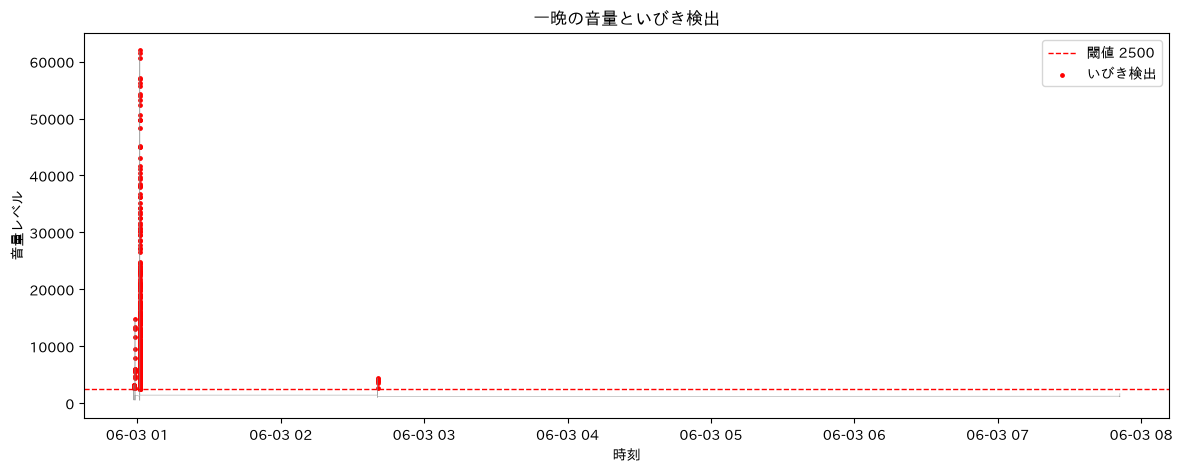

In [6]:
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(df["timestamp"], df["level"], lw=0.4, color="gray", alpha=0.7)
ax.axhline(THRESHOLD, color="red", ls="--", lw=1, label=f"閾値 {THRESHOLD}")
ax.scatter(snore["timestamp"], snore["level"], s=6, color="red", label="いびき検出")
ax.set_xlabel("時刻")
ax.set_ylabel("音量レベル")
ax.set_title("一晩の音量といびき検出")
ax.legend()
plt.show()

## 6. 時間帯別のいびき頻度

1分ごとのいびき検出件数を集計し、どの時間帯にいびきが多かったかを見る。

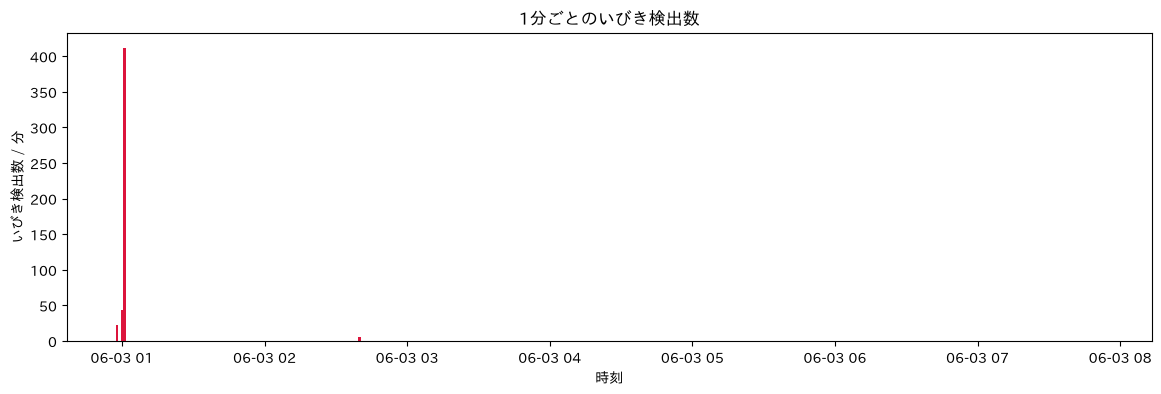

時間帯別 いびき検出数:
timestamp
2026-06-03 00:00:00     23
2026-06-03 01:00:00    456
2026-06-03 02:00:00      6
Freq: h, dtype: int64


In [7]:
per_min = (
    snore.set_index("timestamp")["level"]
    .resample("1min").count()
    .reindex(
        pd.date_range(start.floor("min"), end.ceil("min"), freq="1min"),
        fill_value=0,
    )
)

fig, ax = plt.subplots(figsize=(14, 4))
ax.bar(per_min.index, per_min.values, width=0.0007, color="crimson")
ax.set_xlabel("時刻")
ax.set_ylabel("いびき検出数 / 分")
ax.set_title("1分ごとのいびき検出数")
plt.show()

# 時間帯別の集計
hourly = snore.set_index("timestamp").resample("1h").size()
print("時間帯別 いびき検出数:")
print(hourly)

## 7. まとめ

In [8]:
snore_minutes = (per_min > 0).sum()
print("=== いびき解析サマリー ===")
print(f"記録時間          : {dur_h:.2f} 時間")
print(f"いびきイベント数  : {len(episodes)} 回")
print(f"いびきのあった分数: {snore_minutes} 分 (全体の {snore_minutes/len(per_min)*100:.1f}%)")
print(f"最大ピーク音量    : {episodes['peak_level'].max()}")
print(f"最もいびきが多い時間帯: {hourly.idxmax():%H時台} ({hourly.max()} 件)")

=== いびき解析サマリー ===
記録時間          : 6.88 時間
いびきイベント数  : 4 回
いびきのあった分数: 4 分 (全体の 1.0%)
最大ピーク音量    : 61956
最もいびきが多い時間帯: 01時台 (456 件)
